In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import json
from pathlib import Path


In [4]:
# === Paths ===
RESULTS_DIR = Path("/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/results")
EDA_DIR = RESULTS_DIR / "eda_visualizations"
OUTPUTS_DIR = RESULTS_DIR / "outputs"
EDA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# === Step 1: Reload split & normalized datasets (from Member 4) ===
IMAGE_SIZE = 120
BATCH_SIZE = 32
DATASET_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/data/raw/paddy-disease-classification/train_images"

dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)



Found 14990 files belonging to 8 classes.


In [13]:

# === Step 1: Reload dataset (same IMAGE_SIZE as Member 3) ===
IMAGE_SIZE = 120    # ✅ Keep consistent with Member 3
BATCH_SIZE = 32     # ✅ Same as Member 3
DATASET_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/data/raw/paddy-disease-classification/train_images"
dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)
class_names = dataset.class_names
print("Class names:", class_names)


Found 14990 files belonging to 8 classes.
Class names: ['bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


In [5]:
# --- Reuse Member 3 splitting ---
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)


In [6]:
# --- Reuse Member 4 normalization ---
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))


In [7]:
# === Step 2: Define Data Augmentation ===
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

In [8]:
augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))


Creating augmented samples for visualization...


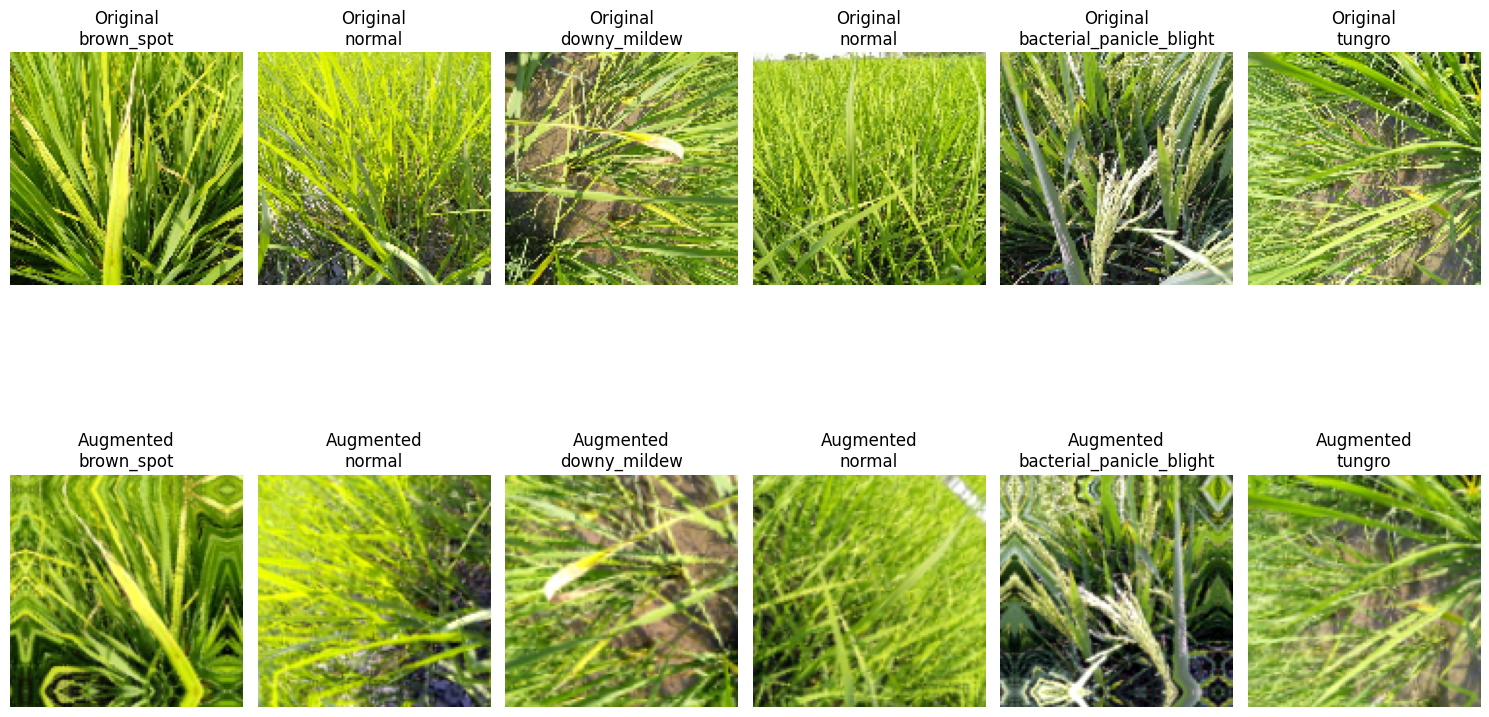

Augmented samples visualization saved!
Saved augmentation report: /content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/results/outputs/augmentation_report.json
🎉 Member 5 Augmentation Completed!


In [14]:
# === Step 4: FIXED - Visualize augmented images (alternative approach) ===
print("Creating augmented samples for visualization...")

# Use original dataset for demonstration
for images, labels in dataset.take(1):
    # Apply normalization manually
    normalized_images = tf.cast(images, tf.float32) / 255.0

    # Apply augmentation manually
    augmented_images = data_augmentation(normalized_images, training=True)

    # Visualize
    plt.figure(figsize=(15, 10))

    # Show original vs augmented (side by side)
    for i in range(6):  # Show 6 samples
        # Original normalized
        ax = plt.subplot(2, 6, i + 1)
        plt.imshow(normalized_images[i])
        plt.title(f"Original\n{class_names[labels[i]]}")
        plt.axis("off")

        # Augmented version
        ax = plt.subplot(2, 6, i + 7)
        plt.imshow(augmented_images[i])
        plt.title(f"Augmented\n{class_names[labels[i]]}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(EDA_DIR / "augmented_sample_images.png", dpi=150)
    plt.show()
    print("Augmented samples visualization saved!")
    break

# === Step 5: Save augmentation report ===
report = {
    "augmentations": [
        "RandomFlip(horizontal)",
        "RandomRotation(0.2)",
        "RandomZoom(0.2)",
        "RandomContrast(0.2)"
    ],
    "applied_to": "train_ds only",
    "status": "completed",
    "visualization": "original_vs_augmented_comparison"
}

with open(OUTPUTS_DIR / "augmentation_report.json", "w") as f:
    json.dump(report, f, indent=2)

print("Saved augmentation report:", OUTPUTS_DIR / "augmentation_report.json")
print("🎉 Member 5 Augmentation Completed!")


